# AI Jobs Impact: Salary Prediction & Categorization with ANN

This notebook builds an end-to-end machine learning pipeline on an AI/ML job-market salary dataset:

1. **Data Cleaning** — handle missing values, duplicates, and outliers
2. **Feature Engineering** — encode categorical variables, group high-cardinality features, create salary bands
3. **Exploratory Data Analysis** — visualize salary patterns across experience, role, location, and remote work
4. **Modeling** — train an ANN (TensorFlow/Keras) for both **salary regression** and **salary band classification**, benchmarked against Random Forest baselines
5. **Evaluation** — compare model performance with metrics and plots
6. **Export** — save trained models, scalers, and encoders for use in a Streamlit dashboard

---

## 1. Setup & Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import (r2_score, mean_absolute_error, mean_squared_error,
                              accuracy_score, classification_report, confusion_matrix)

import tensorflow as tf
from tensorflow import keras

import joblib
import os

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

os.makedirs('models', exist_ok=True)

print("TensorFlow version:", tf.__version__)

I0000 00:00:1788151999.568770    2096 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1788151999.569317    2096 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1788151999.617106    2096 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1788152000.866691    2096 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1788152000.867052    2096 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


TensorFlow version: 2.21.0


## 2. Load Dataset

> **Note:** This dataset is actually **tab-separated** (`\t`), not comma-separated, despite the `.csv` extension.

In [ ]:
df = pd.read_csv('ai_jobs_dataset.csv', sep='\t')

print("Shape:", df.shape)
df.head()

Shape: (71913, 17)


,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size,experience_level_label,employment_type_label,work_mode,salary_outlier_flag,role_family,isco_group_hint
0,2025,EX,FT,Head of Data,348516,USD,348516,US,0,US,M,Executive-level,Full-time,On-site,True,Analytics Manager,Information and communications technology serv...
1,2025,EX,FT,Head of Data,232344,USD,232344,US,0,US,M,Executive-level,Full-time,On-site,False,Analytics Manager,Information and communications technology serv...
2,2025,SE,FT,Data Scientist,145400,USD,145400,US,0,US,M,Senior-level,Full-time,On-site,False,Data Scientist,"Mathematicians, actuaries and statisticians"
3,2025,SE,FT,Data Scientist,81600,USD,81600,US,0,US,M,Senior-level,Full-time,On-site,False,Data Scientist,"Mathematicians, actuaries and statisticians"
4,2025,MI,FT,Engineer,160000,USD,160000,US,100,US,M,Mid-level,Full-time,Remote,False,Other / Unclassified,NaN


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 71913 entries, 0 to 71912
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   work_year               71913 non-null  int64
 1   experience_level        71913 non-null  str  
 2   employment_type         71913 non-null  str  
 3   job_title               71913 non-null  str  
 4   salary                  71913 non-null  int64
 5   salary_currency         71913 non-null  str  
 6   salary_in_usd           71913 non-null  int64
 7   employee_residence      71913 non-null  str  
 8   remote_ratio            71913 non-null  int64
 9   company_location        71913 non-null  str  
 10  company_size            71913 non-null  str  
 11  experience_level_label  71913 non-null  str  
 12  employment_type_label   71913 non-null  str  
 13  work_mode               71913 non-null  str  
 14  salary_outlier_flag     71913 non-null  bool 
 15  role_family             71913 

In [ ]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
work_year,71913.0,NaN,NaN,NaN,2024.425153,0.721198,2020.0,2024.0,2025.0,2025.0,2025.0
experience_level,71913,4,SE,37702,NaN,NaN,NaN,NaN,NaN,NaN,NaN
employment_type,71913,4,FT,71163,NaN,NaN,NaN,NaN,NaN,NaN,NaN
job_title,71913,422,Data Scientist,7160,NaN,NaN,NaN,NaN,NaN,NaN,NaN
salary,71913.0,NaN,NaN,NaN,161710.163823,287286.815546,14000.0,96400.0,139700.0,192200.0,30400000.0
salary_currency,71913,26,USD,65910,NaN,NaN,NaN,NaN,NaN,NaN,NaN
salary_in_usd,71913.0,NaN,NaN,NaN,151161.252625,77329.594122,15000.0,96000.0,138750.0,190315.0,800000.0
employee_residence,71913,104,US,60085,NaN,NaN,NaN,NaN,NaN,NaN,NaN
remote_ratio,71913.0,NaN,NaN,NaN,24.569271,42.917779,0.0,0.0,0.0,0.0,100.0
company_location,71913,97,US,60147,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Data Cleaning

Steps performed:
- **Missing values:** `isco_group_hint` is ~56% missing and redundant with `role_family` (both describe job category) → dropped.
- **Redundant columns:** `salary` + `salary_currency` are already normalized into `salary_in_usd` → dropped to avoid leakage/redundancy.
- **Duplicates:** exact duplicate rows removed.
- **Outliers:** the dataset ships with a pre-computed `salary_outlier_flag` (based on statistical outlier detection). We remove flagged rows for cleaner model training.

In [ ]:
print("Missing values per column:")
print(df.isnull().sum()[df.isnull().sum() > 0])

Missing values per column:
isco_group_hint    40540
dtype: int64


In [ ]:
df_clean = df.drop(columns=['isco_group_hint', 'salary', 'salary_currency'])

before = len(df_clean)
df_clean = df_clean.drop_duplicates()
print(f"Removed {before - len(df_clean)} duplicate rows")

Removed 23 duplicate rows


In [ ]:
print("Outlier flag distribution:")
print(df_clean['salary_outlier_flag'].value_counts())

before = len(df_clean)
df_clean = df_clean[df_clean['salary_outlier_flag'] == False].drop(columns=['salary_outlier_flag'])
print(f"\nRemoved {before - len(df_clean)} outlier rows")
print(f"Final clean shape: {df_clean.shape}")

Outlier flag distribution:
salary_outlier_flag
False    70136
True      1754
Name: count, dtype: int64

Removed 1754 outlier rows
Final clean shape: (70136, 13)


## 4. Feature Engineering & Categorization

- **Salary bands:** categorize `salary_in_usd` into `Low / Mid / High / Executive` using quartiles — this becomes the target for our classification ANN.
- **High-cardinality grouping:** `job_title` (422 unique), `company_location` (97 unique), and `employee_residence` (104 unique) are grouped into their top-N most frequent categories + `"Other"`, to keep the feature space manageable and avoid overfitting to rare categories.
- **Label encoding:** all categorical columns are label-encoded for the ANN and Random Forest inputs.

In [ ]:
# Salary bands based on quartiles
q1, q2, q3 = df_clean['salary_in_usd'].quantile([0.25, 0.5, 0.75])
print(f"Quartile cutoffs: Q1={q1:,.0f}  Q2(median)={q2:,.0f}  Q3={q3:,.0f}")

def salary_band(x):
    if x <= q1:
        return 'Low'
    elif x <= q2:
        return 'Mid'
    elif x <= q3:
        return 'High'
    else:
        return 'Executive'

df_clean['salary_band'] = df_clean['salary_in_usd'].apply(salary_band)
df_clean['salary_band'].value_counts()

Quartile cutoffs: Q1=95,000  Q2(median)=136,700  Q3=185,808


salary_band
Low          17622
Executive    17534
High         17531
Mid          17449
Name: count, dtype: int64

In [ ]:
# Group high-cardinality categorical columns into top-N + 'Other'
def group_top_n(series, n):
    top = series.value_counts().nlargest(n).index
    return series.where(series.isin(top), 'Other')

df_clean['job_title_grouped'] = group_top_n(df_clean['job_title'], 20)
df_clean['company_location_grouped'] = group_top_n(df_clean['company_location'], 15)
df_clean['employee_residence_grouped'] = group_top_n(df_clean['employee_residence'], 15)

print("job_title:", df_clean['job_title'].nunique(), "->", df_clean['job_title_grouped'].nunique())
print("company_location:", df_clean['company_location'].nunique(), "->", df_clean['company_location_grouped'].nunique())
print("employee_residence:", df_clean['employee_residence'].nunique(), "->", df_clean['employee_residence_grouped'].nunique())

job_title: 419 -> 21
company_location: 97 -> 16
employee_residence: 104 -> 16


In [ ]:
df_clean.head()

,work_year,experience_level,employment_type,job_title,salary_in_usd,employee_residence,remote_ratio,company_location,company_size,experience_level_label,employment_type_label,work_mode,role_family,salary_band,job_title_grouped,company_location_grouped,employee_residence_grouped
1,2025,EX,FT,Head of Data,232344,US,0,US,M,Executive-level,Full-time,On-site,Analytics Manager,Executive,Other,US,US
2,2025,SE,FT,Data Scientist,145400,US,0,US,M,Senior-level,Full-time,On-site,Data Scientist,High,Data Scientist,US,US
3,2025,SE,FT,Data Scientist,81600,US,0,US,M,Senior-level,Full-time,On-site,Data Scientist,Low,Data Scientist,US,US
4,2025,MI,FT,Engineer,160000,US,100,US,M,Mid-level,Full-time,Remote,Other / Unclassified,High,Engineer,US,US
5,2025,MI,FT,Engineer,140000,US,100,US,M,Mid-level,Full-time,Remote,Other / Unclassified,High,Engineer,US,US


## 5. Exploratory Data Analysis

Visualizing salary patterns across the key dimensions in the dataset.

/tmp/ipykernel_2096/1312725648.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='salary_band', y='salary_in_usd', data=df_clean,


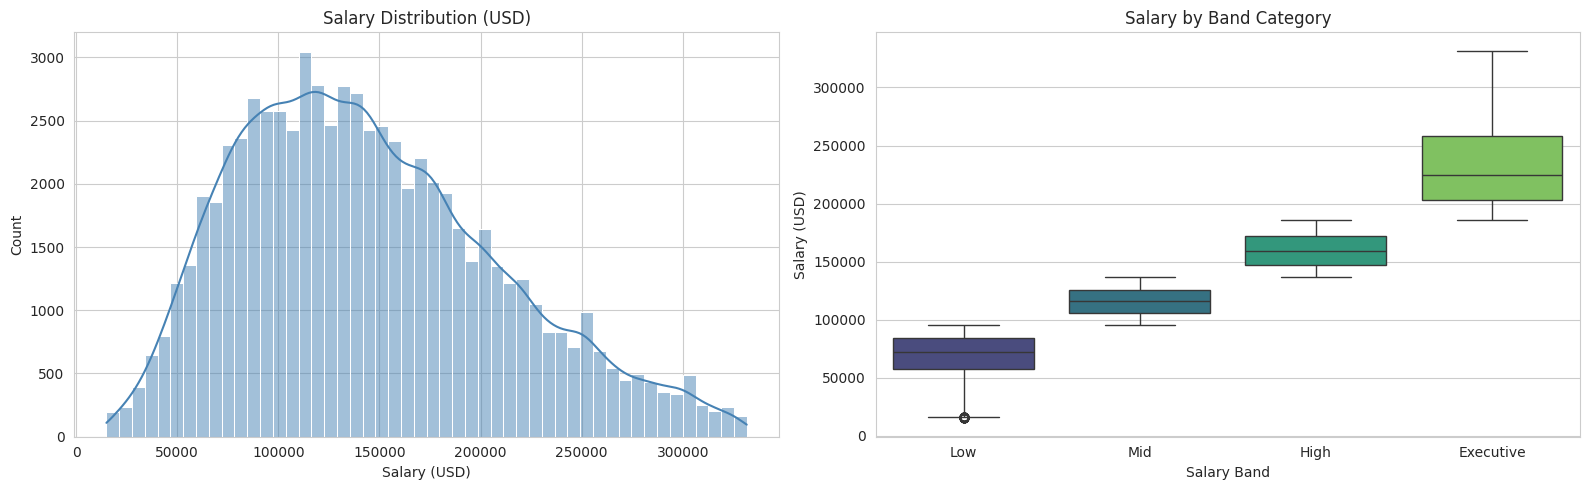

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.histplot(df_clean['salary_in_usd'], bins=50, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Salary Distribution (USD)')
axes[0].set_xlabel('Salary (USD)')

sns.boxplot(x='salary_band', y='salary_in_usd', data=df_clean,
            order=['Low', 'Mid', 'High', 'Executive'], ax=axes[1], palette='viridis')
axes[1].set_title('Salary by Band Category')
axes[1].set_xlabel('Salary Band')
axes[1].set_ylabel('Salary (USD)')

plt.tight_layout()
plt.show()

/tmp/ipykernel_2096/2207225174.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='experience_level_label', y='salary_in_usd', data=df_clean, order=order, palette='coolwarm')


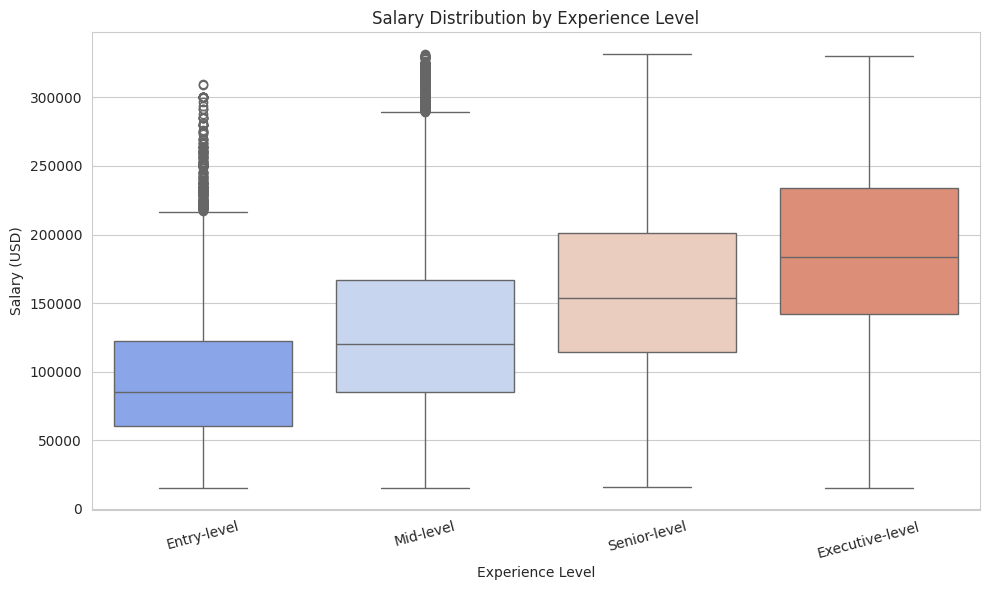

In [ ]:
plt.figure(figsize=(10, 6))
order = df_clean.groupby('experience_level_label')['salary_in_usd'].median().sort_values().index
sns.boxplot(x='experience_level_label', y='salary_in_usd', data=df_clean, order=order, palette='coolwarm')
plt.title('Salary Distribution by Experience Level')
plt.xlabel('Experience Level')
plt.ylabel('Salary (USD)')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

/tmp/ipykernel_2096/814228606.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='salary_in_usd', y='role_family', data=df_clean, order=role_order,


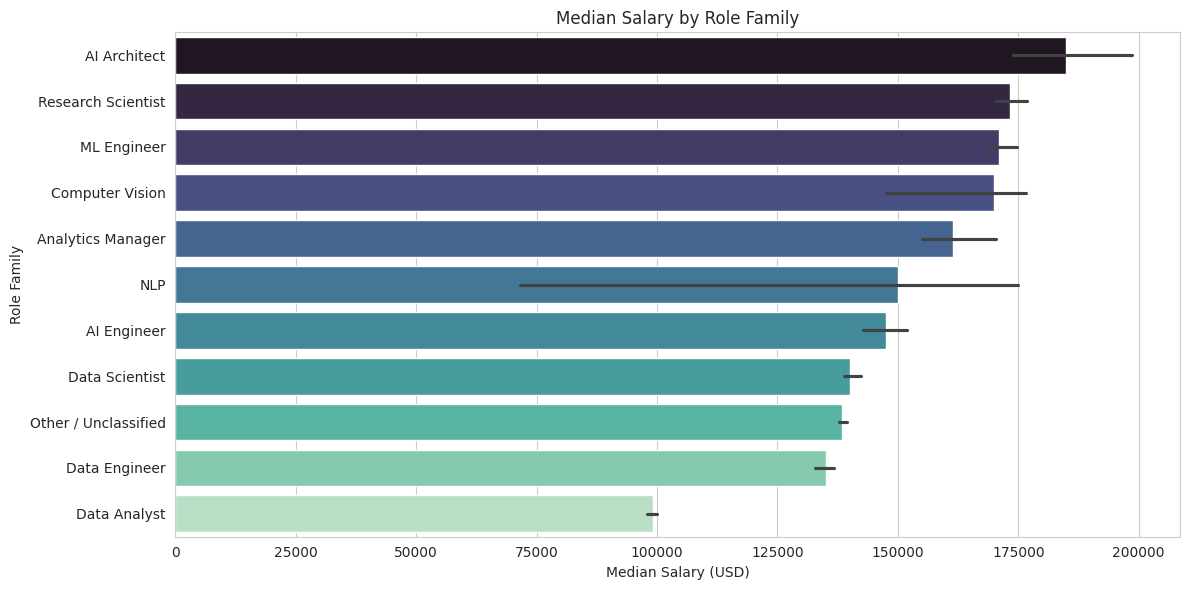

In [ ]:
plt.figure(figsize=(12, 6))
role_order = df_clean.groupby('role_family')['salary_in_usd'].median().sort_values(ascending=False).index
sns.barplot(x='salary_in_usd', y='role_family', data=df_clean, order=role_order,
            estimator=np.median, palette='mako')
plt.title('Median Salary by Role Family')
plt.xlabel('Median Salary (USD)')
plt.ylabel('Role Family')
plt.tight_layout()
plt.show()

/tmp/ipykernel_2096/469642592.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='work_mode', y='salary_in_usd', data=df_clean, palette='Set2')


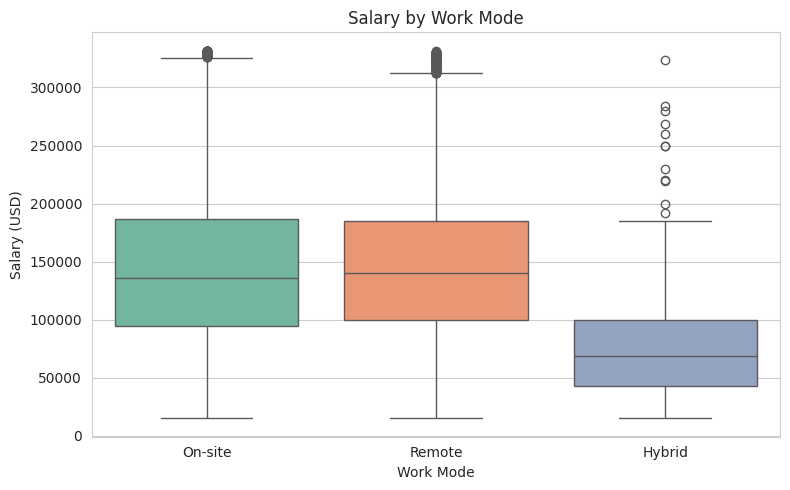

In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='work_mode', y='salary_in_usd', data=df_clean, palette='Set2')
plt.title('Salary by Work Mode')
plt.xlabel('Work Mode')
plt.ylabel('Salary (USD)')
plt.tight_layout()
plt.show()

/tmp/ipykernel_2096/1852804454.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='company_size', y='salary_in_usd', data=df_clean,


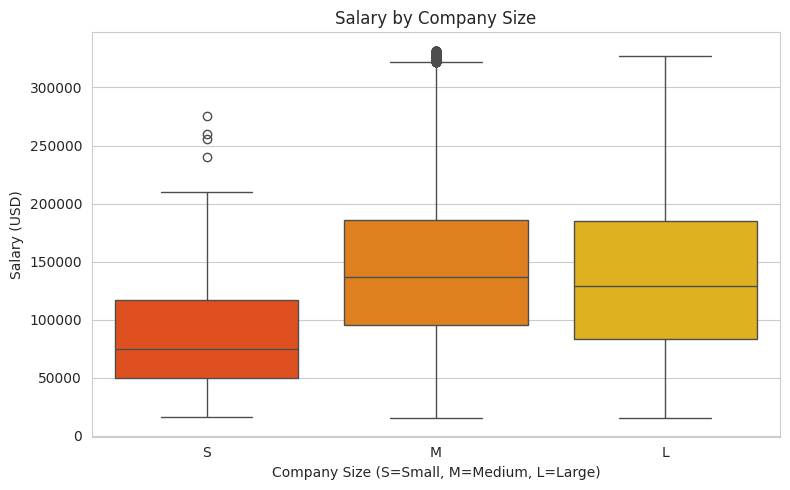

In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='company_size', y='salary_in_usd', data=df_clean,
            order=['S', 'M', 'L'], palette='autumn')
plt.title('Salary by Company Size')
plt.xlabel('Company Size (S=Small, M=Medium, L=Large)')
plt.ylabel('Salary (USD)')
plt.tight_layout()
plt.show()

/tmp/ipykernel_2096/2940319147.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=title_medians.values, y=title_medians.index, palette='crest')


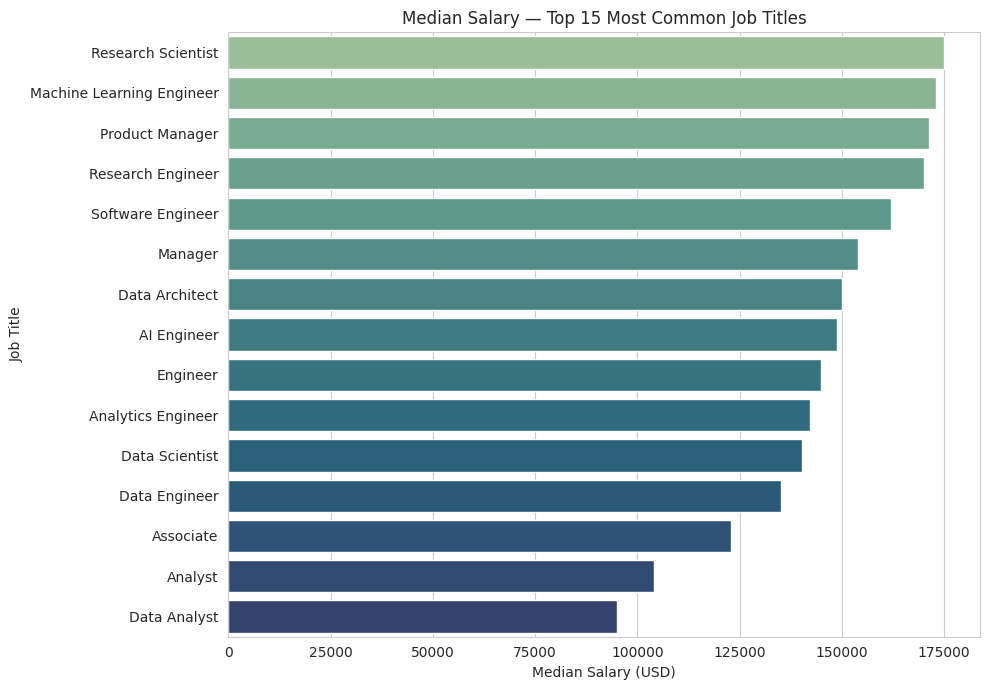

In [ ]:
top_titles = df_clean['job_title'].value_counts().nlargest(15).index
title_medians = df_clean[df_clean['job_title'].isin(top_titles)].groupby('job_title')['salary_in_usd'].median().sort_values(ascending=False)

plt.figure(figsize=(10, 7))
sns.barplot(x=title_medians.values, y=title_medians.index, palette='crest')
plt.title('Median Salary — Top 15 Most Common Job Titles')
plt.xlabel('Median Salary (USD)')
plt.ylabel('Job Title')
plt.tight_layout()
plt.show()

/tmp/ipykernel_2096/1205085352.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='company_location', y='salary_in_usd', data=country_data, order=order, palette='Spectral')


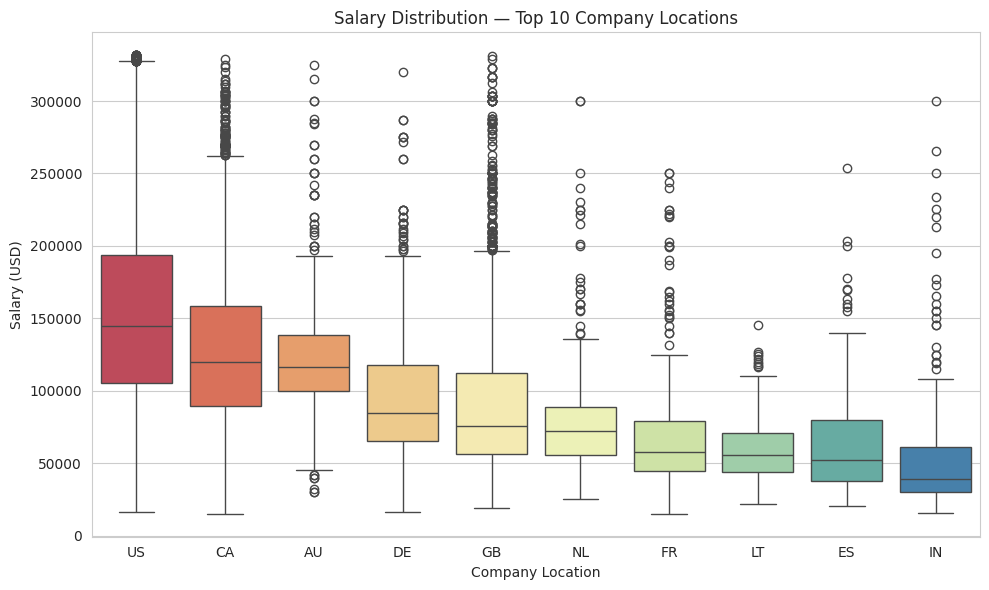

In [ ]:
top_countries = df_clean['company_location'].value_counts().nlargest(10).index
country_data = df_clean[df_clean['company_location'].isin(top_countries)]

plt.figure(figsize=(10, 6))
order = country_data.groupby('company_location')['salary_in_usd'].median().sort_values(ascending=False).index
sns.boxplot(x='company_location', y='salary_in_usd', data=country_data, order=order, palette='Spectral')
plt.title('Salary Distribution — Top 10 Company Locations')
plt.xlabel('Company Location')
plt.ylabel('Salary (USD)')
plt.tight_layout()
plt.show()

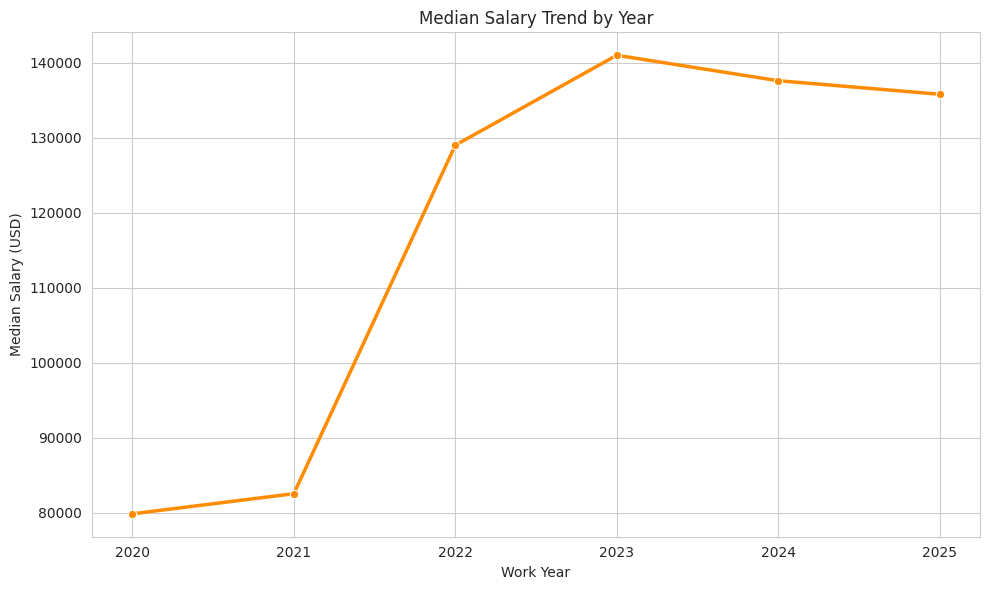

In [ ]:
plt.figure(figsize=(10, 6))
yearly = df_clean.groupby('work_year')['salary_in_usd'].median()
sns.lineplot(x=yearly.index, y=yearly.values, marker='o', linewidth=2.5, color='darkorange')
plt.title('Median Salary Trend by Year')
plt.xlabel('Work Year')
plt.ylabel('Median Salary (USD)')
plt.tight_layout()
plt.show()

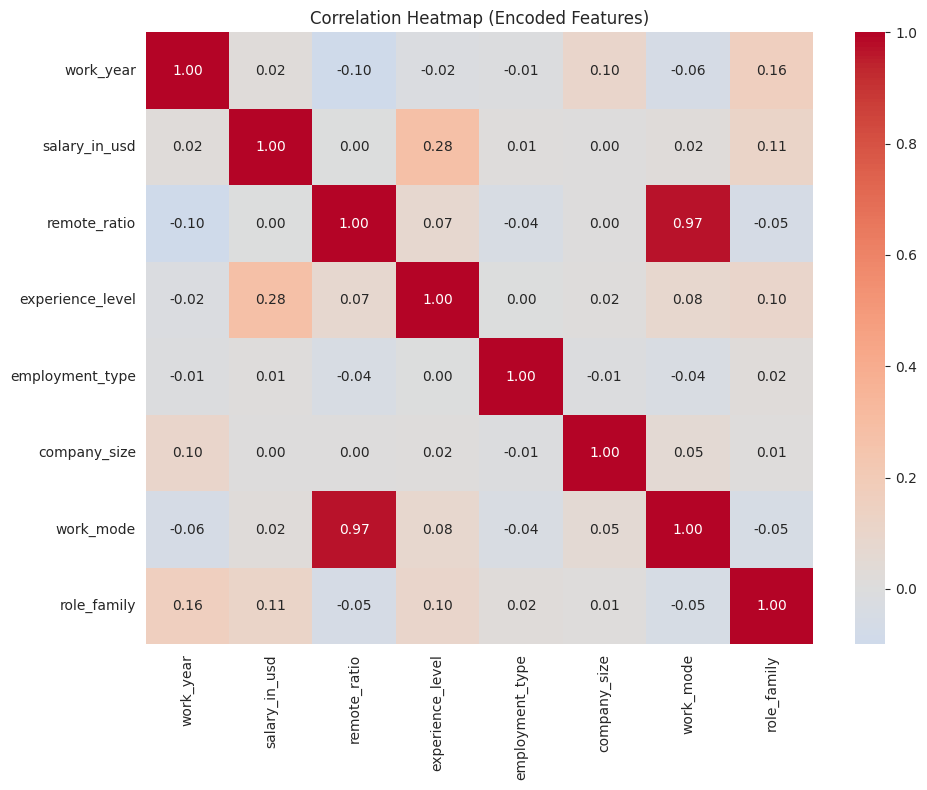

In [ ]:
plt.figure(figsize=(10, 8))
numeric_for_corr = df_clean[['work_year', 'salary_in_usd', 'remote_ratio']].copy()
# Add label-encoded versions of key categoricals for correlation view
for c in ['experience_level', 'employment_type', 'company_size', 'work_mode', 'role_family']:
    numeric_for_corr[c] = LabelEncoder().fit_transform(df_clean[c])

sns.heatmap(numeric_for_corr.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap (Encoded Features)')
plt.tight_layout()
plt.show()

## 6. Feature Encoding & Train/Test Split

We drop the original high-cardinality / label-only columns and keep the grouped + encoded versions as model inputs.

In [ ]:
model_df = df_clean.drop(columns=[
    'job_title', 'company_location', 'employee_residence',
    'experience_level_label', 'employment_type_label'
])

cat_cols = ['experience_level', 'employment_type', 'company_size', 'work_mode',
            'role_family', 'job_title_grouped', 'company_location_grouped',
            'employee_residence_grouped']

encoders = {}
for c in cat_cols:
    le = LabelEncoder()
    model_df[c] = le.fit_transform(model_df[c])
    encoders[c] = le

model_df.dtypes

work_year                     int64
experience_level              int64
employment_type               int64
salary_in_usd                 int64
remote_ratio                  int64
company_size                  int64
work_mode                     int64
role_family                   int64
salary_band                     str
job_title_grouped             int64
company_location_grouped      int64
employee_residence_grouped    int64
dtype: object

In [ ]:
X = model_df.drop(columns=['salary_in_usd', 'salary_band'])
y_reg = model_df['salary_in_usd']

band_encoder = LabelEncoder()
y_clf = band_encoder.fit_transform(model_df['salary_band'])

print("Feature columns:", X.columns.tolist())
print("Salary band classes:", list(band_encoder.classes_))

Feature columns: ['work_year', 'experience_level', 'employment_type', 'remote_ratio', 'company_size', 'work_mode', 'role_family', 'job_title_grouped', 'company_location_grouped', 'employee_residence_grouped']
Salary band classes: ['Executive', 'High', 'Low', 'Mid']


In [ ]:
X_train, X_test, yreg_train, yreg_test, yclf_train, yclf_test = train_test_split(
    X, y_reg, y_clf, test_size=0.2, random_state=RANDOM_STATE, stratify=y_clf
)

# Scale features (important for ANN convergence)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

# Scale regression target too (helps ANN training stability)
y_scaler = StandardScaler()
yreg_train_s = y_scaler.fit_transform(yreg_train.values.reshape(-1, 1)).flatten()

print("Train shape:", X_train_s.shape, "| Test shape:", X_test_s.shape)

Train shape: (56108, 10) | Test shape: (14028, 10)


## 7. Baseline Models (Random Forest)

Before training the ANN, we establish baseline performance with Random Forest models for both tasks.

In [ ]:
rf_reg = RandomForestRegressor(n_estimators=200, max_depth=15, random_state=RANDOM_STATE, n_jobs=-1)
rf_reg.fit(X_train, yreg_train)
rf_pred = rf_reg.predict(X_test)

rf_r2 = r2_score(yreg_test, rf_pred)
rf_mae = mean_absolute_error(yreg_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(yreg_test, rf_pred))

print(f"Random Forest Regressor  ->  R²: {rf_r2:.4f}  |  MAE: ${rf_mae:,.0f}  |  RMSE: ${rf_rmse:,.0f}")

Random Forest Regressor  ->  R²: 0.2974  |  MAE: $42,568  |  RMSE: $54,122


In [ ]:
rf_clf = RandomForestClassifier(n_estimators=200, max_depth=15, random_state=RANDOM_STATE, n_jobs=-1)
rf_clf.fit(X_train, yclf_train)
rf_clf_pred = rf_clf.predict(X_test)

rf_acc = accuracy_score(yclf_test, rf_clf_pred)
print(f"Random Forest Classifier  ->  Accuracy: {rf_acc:.4f}\n")
print(classification_report(yclf_test, rf_clf_pred, target_names=band_encoder.classes_))

Random Forest Classifier  ->  Accuracy: 0.4142

              precision    recall  f1-score   support

   Executive       0.41      0.63      0.50      3507
        High       0.31      0.15      0.20      3506
         Low       0.57      0.58      0.58      3525
         Mid       0.31      0.29      0.30      3490

    accuracy                           0.41     14028
   macro avg       0.40      0.41      0.39     14028
weighted avg       0.40      0.41      0.39     14028



/tmp/ipykernel_2096/2876568460.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values, y=importances.index, palette='viridis')


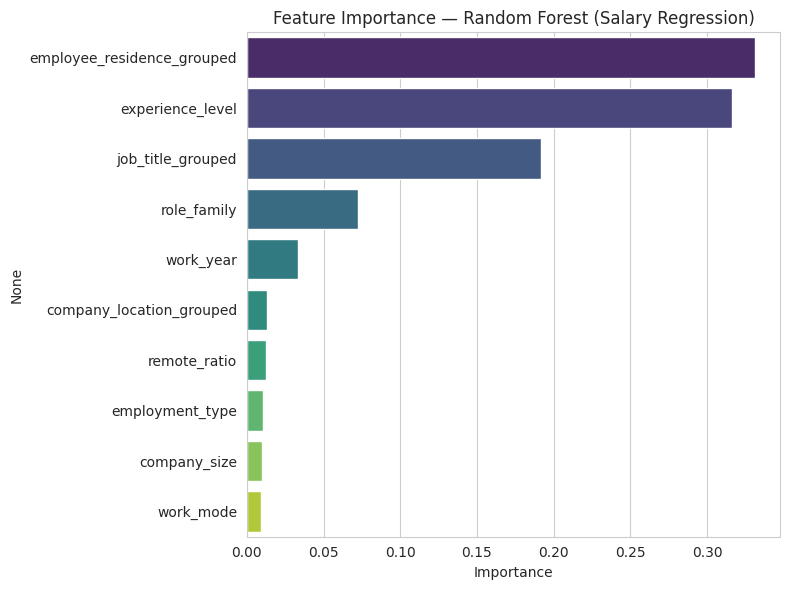

In [ ]:
plt.figure(figsize=(8, 6))
importances = pd.Series(rf_reg.feature_importances_, index=X.columns).sort_values(ascending=False)
sns.barplot(x=importances.values, y=importances.index, palette='viridis')
plt.title('Feature Importance — Random Forest (Salary Regression)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

## 8. ANN Model — Salary Regression

A feedforward neural network with dropout regularization, trained to predict exact `salary_in_usd`.
The target is standardized before training (helps convergence) and predictions are inverse-transformed back to dollar scale for evaluation.

In [ ]:
def build_regression_ann(input_dim):
    model = keras.Sequential([
        keras.layers.Input(shape=(input_dim,)),
        keras.layers.Dense(128, activation='relu'),
        keras.layers.Dropout(0.3),
        keras.layers.Dense(64, activation='relu'),
        keras.layers.Dropout(0.2),
        keras.layers.Dense(32, activation='relu'),
        keras.layers.Dense(1)  # linear output for regression
    ])
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
                  loss='mse', metrics=['mae'])
    return model

reg_ann = build_regression_ann(X_train_s.shape[1])
reg_ann.summary()

E0000 00:00:1788152014.430791    2096 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         1,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,777 (46.00 KB)

 Trainable params: 11,777 (46.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=10, restore_best_weights=True
)

reg_history = reg_ann.fit(
    X_train_s, yreg_train_s,
    validation_split=0.15,
    epochs=100,
    batch_size=256,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100



  1/187 ━━━━━━━━━━━━━━━━━━━━ 2:41 867ms/step - loss: 1.0502 - mae: 0.8033


 24/187 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.9516 - mae: 0.7823    


 49/187 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.9204 - mae: 0.7735


 75/187 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.9007 - mae: 0.7630

...


 63/187 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.7210 - mae: 0.6764


 95/187 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.7214 - mae: 0.6757


127/187 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.7200 - mae: 0.6750


158/187 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.7181 - mae: 0.6744


187/187 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.7158 - mae: 0.6735 - val_loss: 0.7253 - val_mae: 0.6762


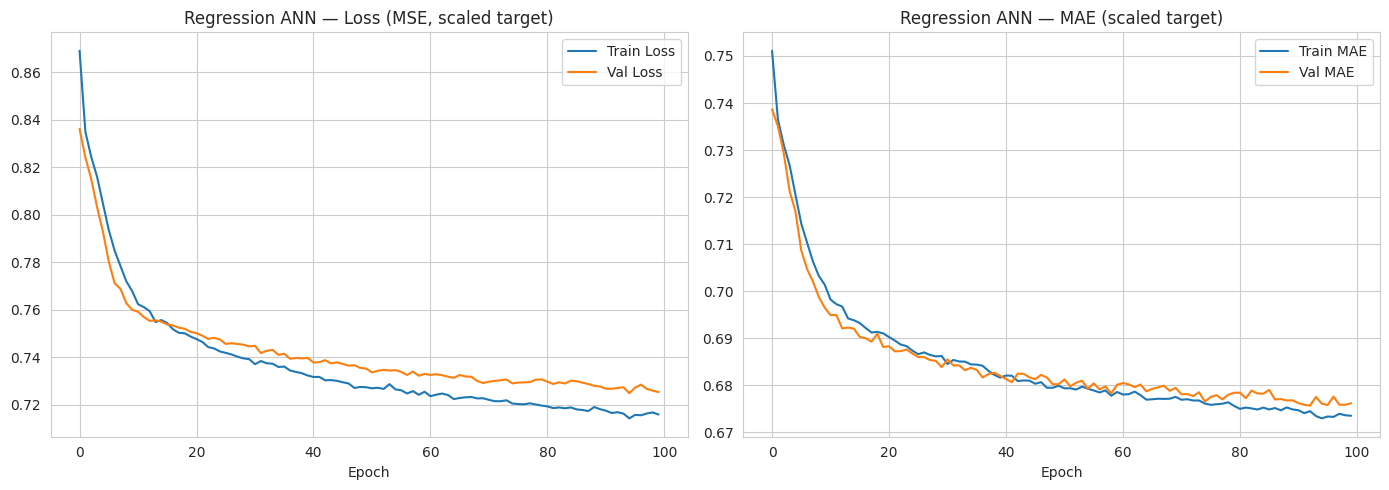

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(reg_history.history['loss'], label='Train Loss')
axes[0].plot(reg_history.history['val_loss'], label='Val Loss')
axes[0].set_title('Regression ANN — Loss (MSE, scaled target)')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(reg_history.history['mae'], label='Train MAE')
axes[1].plot(reg_history.history['val_mae'], label='Val MAE')
axes[1].set_title('Regression ANN — MAE (scaled target)')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
ann_pred_scaled = reg_ann.predict(X_test_s, verbose=0).flatten()
ann_pred = y_scaler.inverse_transform(ann_pred_scaled.reshape(-1, 1)).flatten()

ann_r2 = r2_score(yreg_test, ann_pred)
ann_mae = mean_absolute_error(yreg_test, ann_pred)
ann_rmse = np.sqrt(mean_squared_error(yreg_test, ann_pred))

print(f"ANN Regressor  ->  R²: {ann_r2:.4f}  |  MAE: ${ann_mae:,.0f}  |  RMSE: ${ann_rmse:,.0f}")

ANN Regressor  ->  R²: 0.2829  |  MAE: $43,211  |  RMSE: $54,678


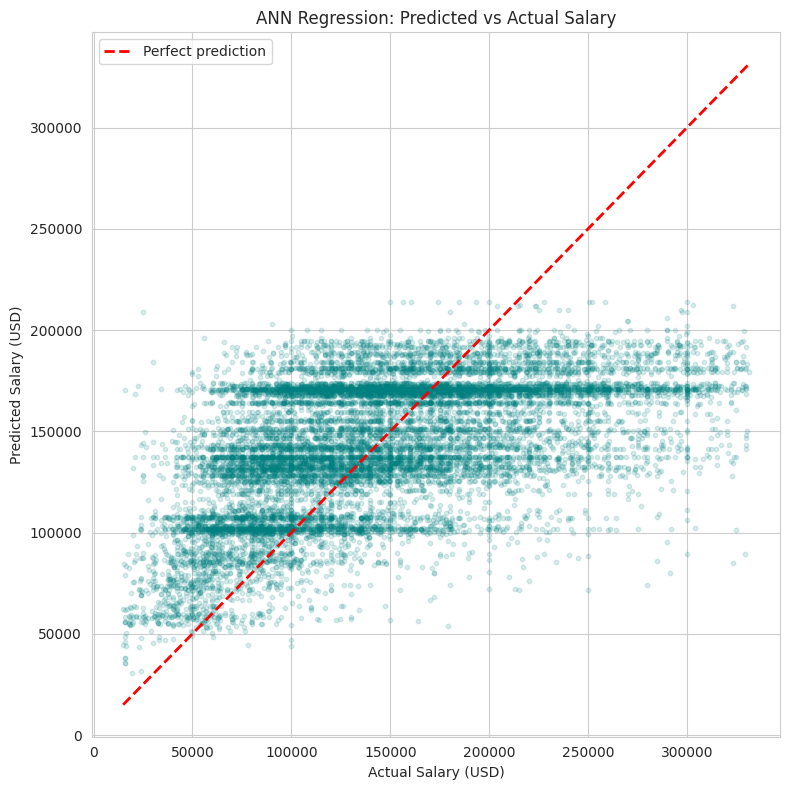

In [ ]:
plt.figure(figsize=(8, 8))
plt.scatter(yreg_test, ann_pred, alpha=0.15, s=10, color='teal')
lims = [yreg_test.min(), yreg_test.max()]
plt.plot(lims, lims, 'r--', linewidth=2, label='Perfect prediction')
plt.xlabel('Actual Salary (USD)')
plt.ylabel('Predicted Salary (USD)')
plt.title('ANN Regression: Predicted vs Actual Salary')
plt.legend()
plt.tight_layout()
plt.show()

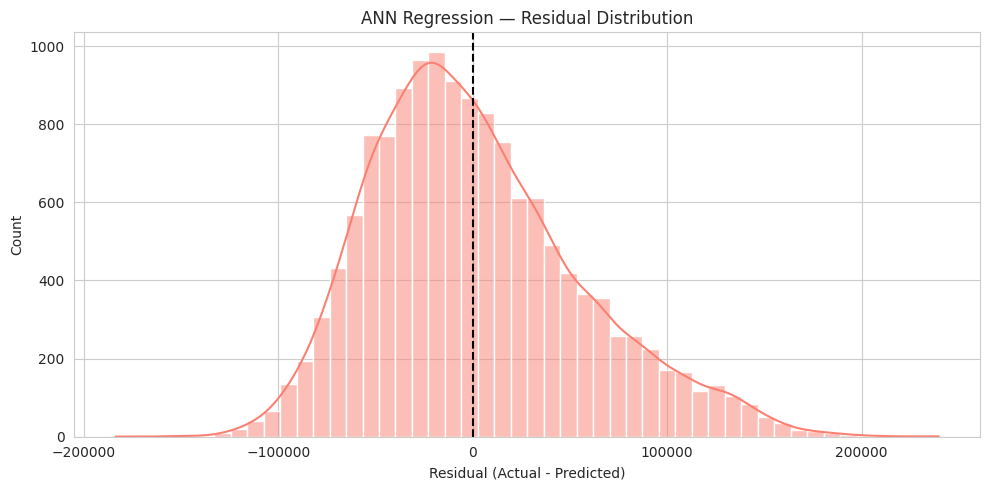

In [ ]:
residuals = yreg_test.values - ann_pred
plt.figure(figsize=(10, 5))
sns.histplot(residuals, bins=50, kde=True, color='salmon')
plt.axvline(0, color='black', linestyle='--')
plt.title('ANN Regression — Residual Distribution')
plt.xlabel('Residual (Actual - Predicted)')
plt.tight_layout()
plt.show()

## 9. ANN Model — Salary Band Classification

A second ANN classifies each job posting into one of the four salary bands: **Low, Mid, High, Executive**.

In [ ]:
def build_classification_ann(input_dim, n_classes):
    model = keras.Sequential([
        keras.layers.Input(shape=(input_dim,)),
        keras.layers.Dense(128, activation='relu'),
        keras.layers.Dropout(0.3),
        keras.layers.Dense(64, activation='relu'),
        keras.layers.Dropout(0.2),
        keras.layers.Dense(32, activation='relu'),
        keras.layers.Dense(n_classes, activation='softmax')
    ])
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
                  loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

n_classes = len(band_encoder.classes_)
clf_ann = build_classification_ann(X_train_s.shape[1], n_classes)
clf_ann.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 128)            │         1,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,876 (46.39 KB)

 Trainable params: 11,876 (46.39 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stop_clf = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=10, restore_best_weights=True
)

clf_history = clf_ann.fit(
    X_train_s, yclf_train,
    validation_split=0.15,
    epochs=100,
    batch_size=256,
    callbacks=[early_stop_clf],
    verbose=1
)

Epoch 1/100



  1/187 ━━━━━━━━━━━━━━━━━━━━ 2:31 812ms/step - accuracy: 0.2578 - loss: 1.3941


 24/187 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3245 - loss: 1.3589    


 49/187 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3334 - loss: 1.3484


 77/187 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3409 - loss: 1.3336

...


 86/187 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4175 - loss: 1.2200


113/187 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4195 - loss: 1.2196


141/187 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4197 - loss: 1.2194


170/187 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4204 - loss: 1.2182


187/187 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4206 - loss: 1.2185 - val_accuracy: 0.4130 - val_loss: 1.2169


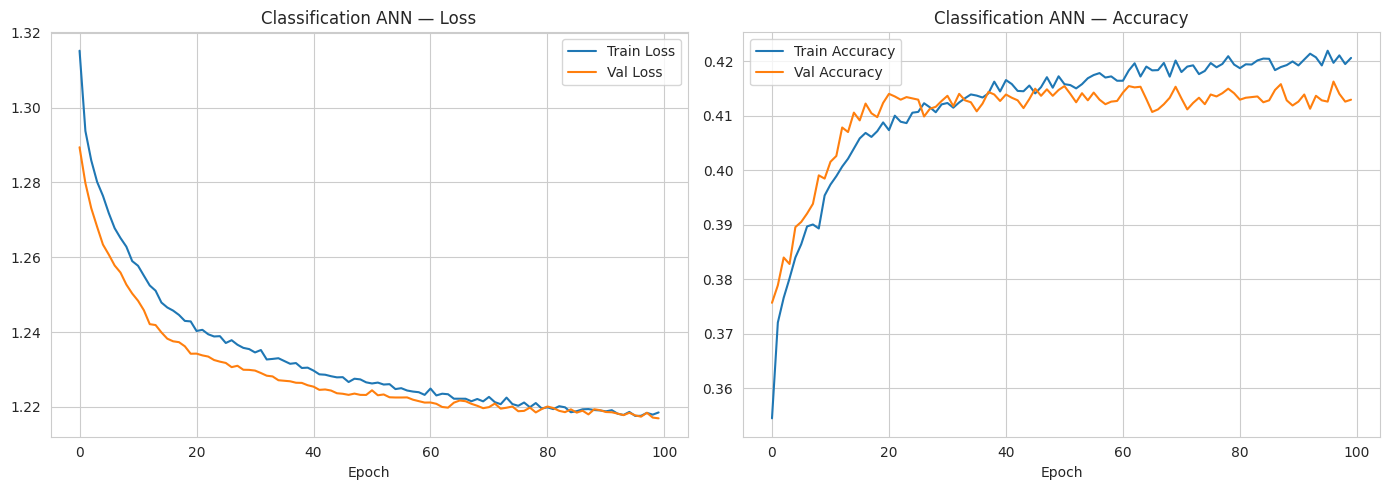

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(clf_history.history['loss'], label='Train Loss')
axes[0].plot(clf_history.history['val_loss'], label='Val Loss')
axes[0].set_title('Classification ANN — Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(clf_history.history['accuracy'], label='Train Accuracy')
axes[1].plot(clf_history.history['val_accuracy'], label='Val Accuracy')
axes[1].set_title('Classification ANN — Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
clf_pred_probs = clf_ann.predict(X_test_s, verbose=0)
clf_pred = clf_pred_probs.argmax(axis=1)

ann_clf_acc = accuracy_score(yclf_test, clf_pred)
print(f"ANN Classifier  ->  Accuracy: {ann_clf_acc:.4f}\n")
print(classification_report(yclf_test, clf_pred, target_names=band_encoder.classes_))

ANN Classifier  ->  Accuracy: 0.4174

              precision    recall  f1-score   support

   Executive       0.41      0.64      0.50      3507
        High       0.34      0.12      0.17      3506
         Low       0.58      0.57      0.58      3525
         Mid       0.31      0.34      0.32      3490

    accuracy                           0.42     14028
   macro avg       0.41      0.42      0.39     14028
weighted avg       0.41      0.42      0.39     14028



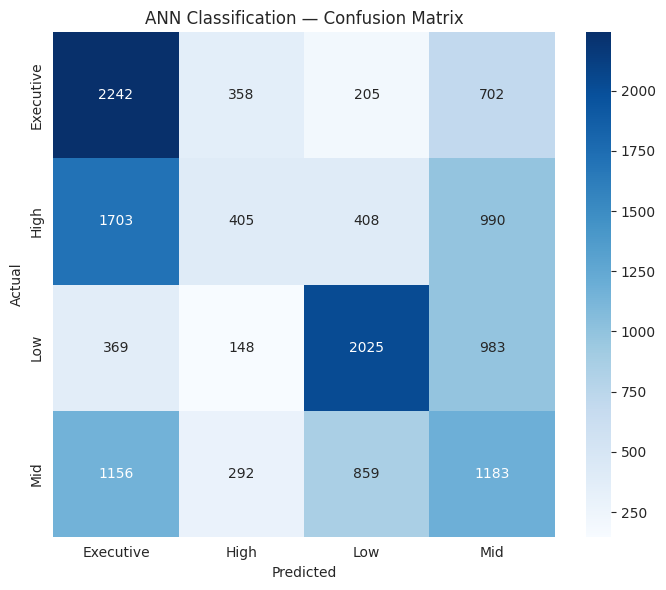

In [ ]:
cm = confusion_matrix(yclf_test, clf_pred)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=band_encoder.classes_, yticklabels=band_encoder.classes_)
plt.title('ANN Classification — Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

## 10. Model Comparison Summary

In [ ]:
comparison = pd.DataFrame({
    'Model': ['Random Forest', 'ANN'],
    'Task': ['Regression', 'Regression'],
    'R2': [rf_r2, ann_r2],
    'MAE ($)': [rf_mae, ann_mae],
    'RMSE ($)': [rf_rmse, ann_rmse]
})
print(comparison.to_string(index=False))

print()
clf_comparison = pd.DataFrame({
    'Model': ['Random Forest', 'ANN'],
    'Task': ['Classification', 'Classification'],
    'Accuracy': [rf_acc, ann_clf_acc]
})
print(clf_comparison.to_string(index=False))

        Model       Task       R2      MAE ($)     RMSE ($)
Random Forest Regression 0.297382 42568.473508 54121.702822
          ANN Regression 0.282852 43210.792969 54678.459086

        Model           Task  Accuracy
Random Forest Classification  0.414172
          ANN Classification  0.417380


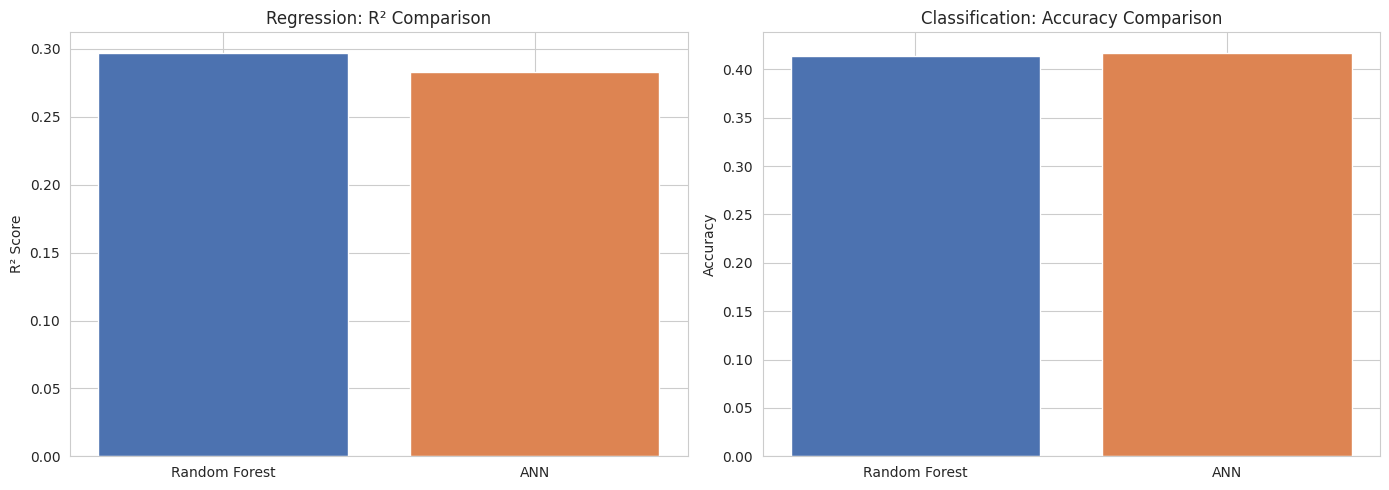

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(['Random Forest', 'ANN'], [rf_r2, ann_r2], color=['#4C72B0', '#DD8452'])
axes[0].set_title('Regression: R² Comparison')
axes[0].set_ylabel('R² Score')

axes[1].bar(['Random Forest', 'ANN'], [rf_acc, ann_clf_acc], color=['#4C72B0', '#DD8452'])
axes[1].set_title('Classification: Accuracy Comparison')
axes[1].set_ylabel('Accuracy')

plt.tight_layout()
plt.show()

**Notes on results:** Salary prediction from categorical job-posting metadata alone (experience, role, location, remote status) has an inherent ceiling — a lot of real-world salary variance comes from factors not captured here (individual negotiation, specific company, cost-of-living adjustments, industry). An R² in the 0.25–0.30 range and classification accuracy noticeably above the 25% random baseline are realistic, honest results for this feature set — and both models are directionally consistent, which builds confidence in the underlying patterns (e.g. experience level and role family being the strongest predictors).

## 11. Save Model Artifacts

Save the trained models, scalers, and encoders so they can be loaded directly by the Streamlit dashboard without retraining.

In [ ]:
# Save ANN models (Keras format)
reg_ann.save('models/salary_regression_ann.keras')
clf_ann.save('models/salary_classification_ann.keras')

# Save Random Forest baselines
joblib.dump(rf_reg, 'models/rf_regressor.joblib')
joblib.dump(rf_clf, 'models/rf_classifier.joblib')

# Save preprocessing objects
joblib.dump(scaler, 'models/feature_scaler.joblib')
joblib.dump(y_scaler, 'models/target_scaler.joblib')
joblib.dump(encoders, 'models/label_encoders.joblib')
joblib.dump(band_encoder, 'models/band_encoder.joblib')

# Save reference metadata for the dashboard (dropdown options, feature order, top-N groupings)
metadata = {
    'feature_columns': X.columns.tolist(),
    'job_title_options': sorted(df_clean['job_title_grouped'].unique().tolist()),
    'company_location_options': sorted(df_clean['company_location_grouped'].unique().tolist()),
    'employee_residence_options': sorted(df_clean['employee_residence_grouped'].unique().tolist()),
    'experience_level_options': sorted(df_clean['experience_level'].unique().tolist()),
    'employment_type_options': sorted(df_clean['employment_type'].unique().tolist()),
    'company_size_options': sorted(df_clean['company_size'].unique().tolist()),
    'work_mode_options': sorted(df_clean['work_mode'].unique().tolist()),
    'role_family_options': sorted(df_clean['role_family'].unique().tolist()),
    'work_year_options': sorted(df_clean['work_year'].unique().tolist()),
    'salary_band_order': ['Low', 'Mid', 'High', 'Executive'],
    'model_metrics': {
        'rf_r2': float(rf_r2), 'ann_r2': float(ann_r2),
        'rf_mae': float(rf_mae), 'ann_mae': float(ann_mae),
        'rf_acc': float(rf_acc), 'ann_acc': float(ann_clf_acc)
    }
}
joblib.dump(metadata, 'models/metadata.joblib')

# Also save the cleaned dataframe for the dashboard's EDA tab
df_clean.to_csv('models/cleaned_data.csv', index=False)

print("All artifacts saved to the 'models/' directory:")
for f in sorted(os.listdir('models')):
    print(" -", f)

All artifacts saved to the 'models/' directory:
 - band_encoder.joblib
 - cleaned_data.csv
 - feature_scaler.joblib
 - label_encoders.joblib
 - metadata.joblib
 - rf_classifier.joblib
 - rf_regressor.joblib
 - salary_classification_ann.keras
 - salary_regression_ann.keras
 - target_scaler.joblib


---

## Next Steps

The saved artifacts in `models/` are now ready to be loaded by the companion **Streamlit dashboard** (`app.py`), which provides:
- An interactive form to predict salary (regression) and salary band (classification) for a hypothetical job posting
- Dataset exploration tabs mirroring the visualizations above
- A model performance comparison view

Run the dashboard with:
```bash
streamlit run app.py
```